# Imports & SetUp

In [1]:
import os
import copy
import json
import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
from pathlib import Path
from typing import Tuple
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, models, transforms, utils
from torch.utils.data import DataLoader, Dataset, random_split, Subset

In [4]:
import pennylane as qml
import pennylane.qnn as qnn

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
from paths_setup import TRAIN_DIR, TEST_DIR, BACKUP_DIR

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")
if not TEST_DIR.exists():
    raise FileNotFoundError(f"TEST_DIR not found: {TEST_DIR}")
if not BACKUP_DIR.exists():
    raise FileNotFoundError(f"BACKUP_DIR not found: {BACKUP_DIR}")

In [7]:
VIEW_CLASS = ["02", "06", "08", "12", "13", "14", "15", "16", "18", "21", "22", "23", "27", "30"]

missing_train = [c for c in VIEW_CLASS if not (TRAIN_DIR / c).exists()]
missing_test  = [c for c in VIEW_CLASS if not (TEST_DIR  / c).exists()]

if missing_train:
    raise FileNotFoundError(f"Missing train class folders: {missing_train}")
if missing_test:
    raise FileNotFoundError(f"Missing test class folders: {missing_test}")

In [8]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
NUM_WORKERS = 8

# Data Exploration

## General Information

In [10]:
def show_first_10_images(folder_dir: Path, view_name: str) -> None:
    
    view_dir = Path(folder_dir) / view_name
    png_files = sorted(view_dir.glob("*.png"))[:10]

    if not view_dir.exists():
        raise FileNotFoundError(f"Folder does not exist: {view_dir}")

    if len(png_files) == 0:
        raise FileNotFoundError(f"No PNG files found in: {view_dir}")

    n = len(png_files)
    rows, cols = 2, 5

    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.axis("off")

        if i < n:
            img = Image.open(png_files[i])
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "EMPTY", ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [11]:
def count_pngs(folder: Path) -> int:
    
    if not folder.exists() or not folder.is_dir():
        return 0
    return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".png")

In [12]:
def print_view_image_counts(view_name: str) -> Tuple[int, int]:

    view_name = str(view_name).strip()
    
    train_view_dir = TRAIN_DIR / view_name
    test_view_dir  = TEST_DIR / view_name

    train_count = count_pngs(train_view_dir)
    test_count  = count_pngs(test_view_dir)

    return train_count, test_count

In [13]:
total_train = 0
total_test  = 0
counts_matrix = []

print(f"--- Data Summary ---")

for vc in VIEW_CLASS:
    temp_train, temp_test = print_view_image_counts(vc)

    counts_matrix.append([temp_train, temp_test])
    
    total_train += temp_train
    total_test  += temp_test
    
    print(f"View {vc}: {temp_train + temp_test} images ({temp_train} train images; {temp_test} test images)")
    
print(f"Total: {total_train + total_test} images ({total_train} train images; {total_test} test images)")

--- Data Summary ---
View 02: 19566 images (15317 train images; 4249 test images)
View 06: 10401 images (10000 train images; 401 test images)
View 08: 13020 images (10272 train images; 2748 test images)
View 12: 22663 images (18030 train images; 4633 test images)
View 13: 17814 images (14385 train images; 3429 test images)
View 14: 11139 images (10000 train images; 1139 test images)
View 15: 31473 images (25052 train images; 6421 test images)
View 16: 12061 images (10000 train images; 2061 test images)
View 18: 11058 images (10000 train images; 1058 test images)
View 21: 14059 images (11160 train images; 2899 test images)
View 22: 10895 images (10000 train images; 895 test images)
View 23: 13723 images (10930 train images; 2793 test images)
View 27: 11670 images (10000 train images; 1670 test images)
View 30: 10803 images (10000 train images; 803 test images)
Total: 210345 images (175146 train images; 35199 test images)


In [14]:
def plot_train_test_counts_stacked(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))

    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", label="Train")
    plt.bar(x, test_counts,  width=0.80, color="C1", label="Test", bottom=train_counts)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train + Test)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
def plot_train_test_counts_overlaid(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))
    
    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", alpha=0.5, label="Train", zorder=1)
    plt.bar(x, test_counts,  width=0.80, color="C1", alpha=0.5, label="Test",  zorder=2)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train and Test - Overlaid)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

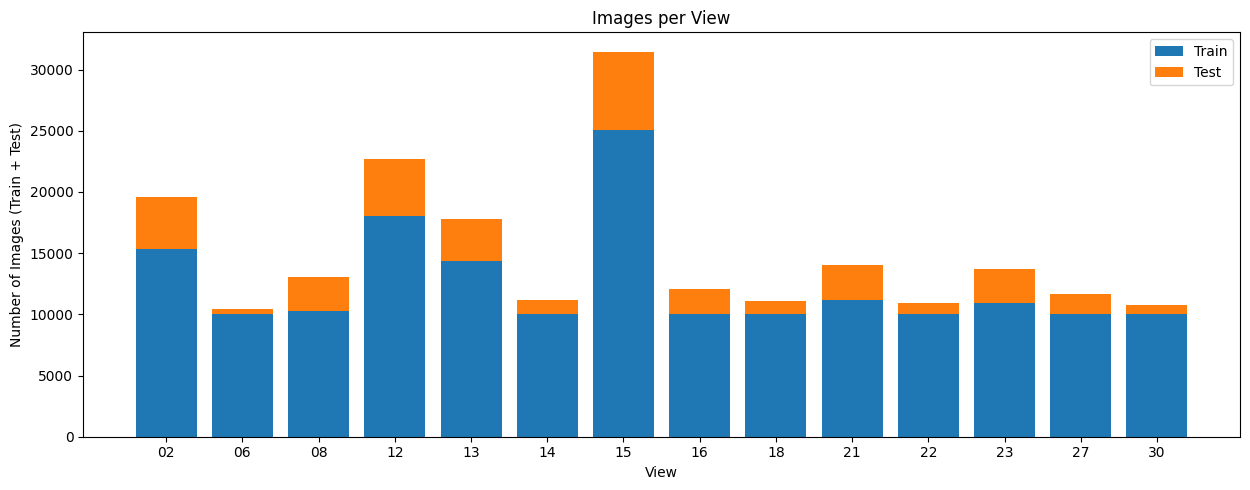

In [16]:
plot_train_test_counts_stacked(VIEW_CLASS, counts_matrix)

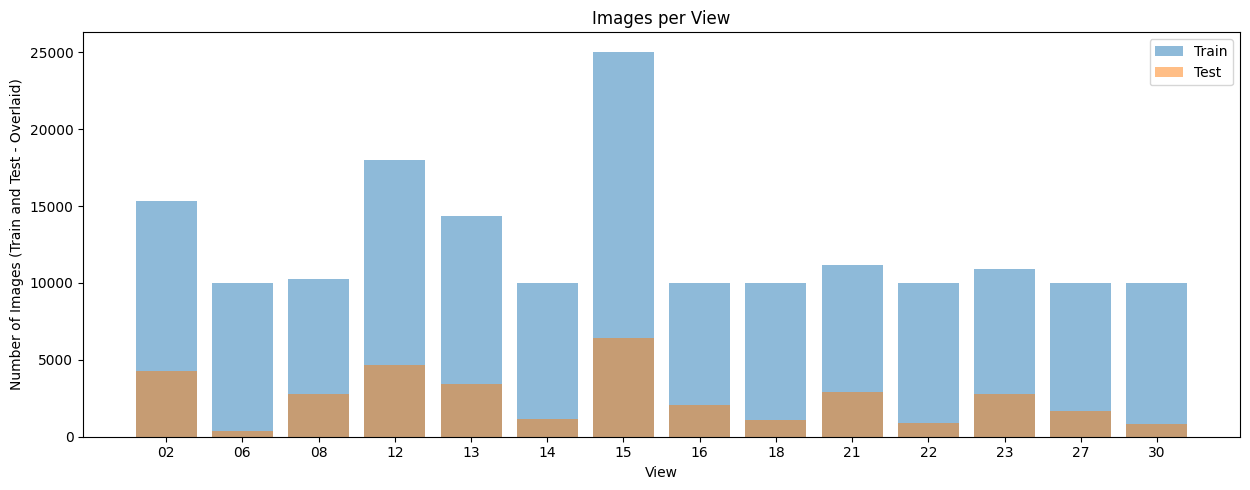

In [17]:
plot_train_test_counts_overlaid(VIEW_CLASS, counts_matrix)

## Label Mapping

In [18]:
class_to_idx = {name: i for i, name in enumerate(VIEW_CLASS)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

print("Label mapping:")
for k in sorted(class_to_idx.keys()):
    print(f"   {k} -> {class_to_idx[k]}")

Label mapping:
   02 -> 0
   06 -> 1
   08 -> 2
   12 -> 3
   13 -> 4
   14 -> 5
   15 -> 6
   16 -> 7
   18 -> 8
   21 -> 9
   22 -> 10
   23 -> 11
   27 -> 12
   30 -> 13


## Check Image Size Consistency

In [19]:
EXCLUDED_FILES = []
run_verify_image_dimensions = 0

In [20]:
def verify_image_dimensions(folder_dir: Path, target_size: Tuple[int, int]) -> None:
    print(f"Checking image dimensions in {folder_dir}:")
    total_mismatch = 0 
    
    for class_name in VIEW_CLASS:
        mismatch_count = 0
        
        print(f"\n   View {class_name}:")
        class_path = folder_dir / class_name
        if not class_path.exists():
            continue
            
        for img_path in class_path.glob("*.png"):
            with Image.open(img_path) as img:
                if img.size != target_size:
                    mismatch_count += 1
                    total_mismatch += 1
                    EXCLUDED_FILES.append(img_path.name)
                    print(f"      Mismatch found: {img_path.name} is {img.size}")

        if mismatch_count == 0:
            print("      No mismatches found")

    if total_mismatch == 0:
        print(f"\nSuccess: All images are confirmed to be {target_size}")
    else:
        print(f"\nWARNING: Found {total_mismatch} images with inconsistent sizes")

In [21]:
verify_image_dimensions(TRAIN_DIR, IMG_SIZE)
verify_image_dimensions(TEST_DIR,  IMG_SIZE)
run_verify_image_dimensions = 1

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/train:

   View 02:
      Mismatch found: __Amy__DicomIMG_ID_69214103__20200810140438__1.png is (432, 288)
      Mismatch found: __DCM__DicomIMG_ID_60302307__nk095938.000000__1.png is (432, 288)

   View 06:
      No mismatches found

   View 08:
      No mismatches found

   View 12:
      No mismatches found

   View 13:
      No mismatches found

   View 14:
      No mismatches found

   View 15:
      No mismatches found

   View 16:
      No mismatches found

   View 18:
      No mismatches found

   View 21:
      No mismatches found

   View 22:
      No mismatches found

   View 23:
      No mismatches found

   View 27:
      No mismatches found

   View 30:
      No mismatches found

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/test:

   View 02:
      No mismatches found

   View 06:
      No mismatches found

   Vie

In [22]:
if run_verify_image_dimensions == 0:
    EXCLUDED_FILES = ['__Amy__DicomIMG_ID_69214103__20200810140438__1.png', '__DCM__DicomIMG_ID_60302307__nk095938.000000__1.png']
print(f"Files to exclude: {EXCLUDED_FILES}")

Files to exclude: ['__Amy__DicomIMG_ID_69214103__20200810140438__1.png', '__DCM__DicomIMG_ID_60302307__nk095938.000000__1.png']


## View 02

In [ ]:
show_first_10_images(TRAIN_DIR, "02")
show_first_10_images(TEST_DIR,  "02")

## View 06

In [ ]:
show_first_10_images(TRAIN_DIR, "06")
show_first_10_images(TEST_DIR,  "06")

## View 08

In [ ]:
show_first_10_images(TRAIN_DIR, "08")
show_first_10_images(TEST_DIR,  "08")

## View 12

In [ ]:
show_first_10_images(TRAIN_DIR, "12")
show_first_10_images(TEST_DIR,  "12")

## View 13

In [ ]:
show_first_10_images(TRAIN_DIR, "13")
show_first_10_images(TEST_DIR,  "13")

## View 14

In [ ]:
show_first_10_images(TRAIN_DIR, "14")
show_first_10_images(TEST_DIR,  "14")

## View 15

In [ ]:
show_first_10_images(TRAIN_DIR, "15")
show_first_10_images(TEST_DIR,  "15")

## View 16

In [ ]:
show_first_10_images(TRAIN_DIR, "16")
show_first_10_images(TEST_DIR,  "16")

## View 18

In [ ]:
show_first_10_images(TRAIN_DIR, "18")
show_first_10_images(TEST_DIR,  "18")

## View 21

In [ ]:
show_first_10_images(TRAIN_DIR, "21")
show_first_10_images(TEST_DIR,  "21")

## View 22

In [ ]:
show_first_10_images(TRAIN_DIR, "22")
show_first_10_images(TEST_DIR,  "22")

## View 23

In [ ]:
show_first_10_images(TRAIN_DIR, "23")
show_first_10_images(TEST_DIR,  "23")

## View 27

In [ ]:
show_first_10_images(TRAIN_DIR, "27")
show_first_10_images(TEST_DIR,  "27")

## View 30

In [ ]:
show_first_10_images(TRAIN_DIR, "30")
show_first_10_images(TEST_DIR,  "30")

# Data Preprocessing

## Data Transforms

In [23]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
}

## Load & Split Data

In [24]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        
        if self.transform:
            x = self.transform(x)
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

In [25]:
def is_valid_image(path):
    if os.path.basename(path) in EXCLUDED_FILES:
        return False 
    return path.lower().endswith('.png')

In [26]:
base_dataset = datasets.ImageFolder(root=TRAIN_DIR, is_valid_file=is_valid_image) 

train_size = int((1 - VAL_SPLIT) * len(base_dataset))
val_size = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(base_dataset, [train_size, val_size], generator=generator)

train_data = TransformedSubset(train_subset, transform=data_transforms['train'])
val_data   = TransformedSubset(val_subset,   transform=data_transforms['val'])

test_data = datasets.ImageFolder(root=TEST_DIR, is_valid_file=is_valid_image, transform=data_transforms['val'])

In [27]:
def get_counts(subset):
    targets = [subset.dataset.targets[i] for i in subset.indices]
    return np.bincount(targets, minlength=len(base_dataset.classes))

train_counts = get_counts(train_subset)
val_counts = get_counts(val_subset)
test_counts = np.bincount(test_data.targets, minlength=len(base_dataset.classes))

print(f"Dataset split (Total = {len(base_dataset) + len(test_data)}):")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Train = {train_counts[i]}, Val = {val_counts[i]}, Test = {test_counts[i]}")

print("Training set size: ", len(train_data))
print("Validation set size: ", len(val_data))
print("Test set size: ", len(test_data))

Dataset split (Total = 210343):
   View 02: Train = 12276, Val = 3039, Test = 4249
   View 06: Train = 7911, Val = 2089, Test = 401
   View 08: Train = 8211, Val = 2061, Test = 2748
   View 12: Train = 14457, Val = 3573, Test = 4633
   View 13: Train = 11455, Val = 2930, Test = 3429
   View 14: Train = 8009, Val = 1991, Test = 1139
   View 15: Train = 20015, Val = 5037, Test = 6421
   View 16: Train = 7995, Val = 2005, Test = 2061
   View 18: Train = 8030, Val = 1970, Test = 1058
   View 21: Train = 8917, Val = 2243, Test = 2899
   View 22: Train = 8037, Val = 1963, Test = 895
   View 23: Train = 8771, Val = 2159, Test = 2793
   View 27: Train = 7971, Val = 2029, Test = 1670
   View 30: Train = 8060, Val = 1940, Test = 803
Training set size:  140115
Validation set size:  35029
Test set size:  35199


## Class Weights

In [28]:
base_targets = train_data.subset.dataset.targets
train_indices = train_data.subset.indices
train_targets = [base_targets[i] for i in train_indices]

class_counts = np.bincount(train_targets)
total_samples = len(train_targets)
num_classes = len(class_counts)

class_weights = total_samples / (num_classes * class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

In [29]:
print("Class weights:")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Count = {class_counts[i]}, Weight = {class_weights[i]:.4f}")

Class weights:
   View 02: Count = 12276, Weight = 0.8153
   View 06: Count = 7911, Weight = 1.2651
   View 08: Count = 8211, Weight = 1.2189
   View 12: Count = 14457, Weight = 0.6923
   View 13: Count = 11455, Weight = 0.8737
   View 14: Count = 8009, Weight = 1.2496
   View 15: Count = 20015, Weight = 0.5000
   View 16: Count = 7995, Weight = 1.2518
   View 18: Count = 8030, Weight = 1.2464
   View 21: Count = 8917, Weight = 1.1224
   View 22: Count = 8037, Weight = 1.2453
   View 23: Count = 8771, Weight = 1.1411
   View 27: Count = 7971, Weight = 1.2556
   View 30: Count = 8060, Weight = 1.2417


## Data Loaders

In [30]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
def show_batch(loader):
    images, labels = next(iter(loader))
    
    print(f"Batch shape: {images.shape}")
    
    plt.figure(figsize=(16, 8))
    
    images = images * 0.5 + 0.5 
    
    grid_img = utils.make_grid(images, nrow=8, padding=2)
    
    plt.imshow(grid_img.permute(1, 2, 0), cmap="gray")
    plt.axis('off')
    plt.title("Batch of Preprocessed Training Images (Grayscale)")
    plt.show()

show_batch(train_loader)

# Testing Models

## Utility Functions

In [31]:
num_classes = len(base_dataset.classes)

In [32]:
class_mapping_path = BACKUP_DIR / "class_mapping.json"
with open(class_mapping_path, "w") as f:
    json.dump(base_dataset.classes, f)
print(f"Saved class mapping")

Saved class mapping


In [33]:
def train_model(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_val_acc = 0.0
    best_train_acc = 0.0
    
    print(f"Starting training {model_name} model for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())

                if epoch_acc > best_train_acc:
                    best_train_acc = epoch_acc
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print()

    print(f'\nBest Val Acc:   {best_val_acc:.4f}')
    print(f'Best Train Acc: {best_train_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

In [34]:
def plot_learning_curves(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)
    
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    plt.scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    
    plt.legend(loc='lower right')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    plt.scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [35]:
def evaluate_model(model, dataloader, classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

In [36]:
def save_model(trained_model, model_path, model_name):
    torch.save(trained_model.state_dict(), BACKUP_DIR / model_path)
    print(f"Saved model weights for {model_name}: {model_path}")

## K-Fold

In [37]:
def cross_validate_model(model_class, train_dataset, num_epochs, k_folds, num_workers):
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    
    all_targets = [s[1] for s in train_dataset.samples]
    
    splits = list(skf.split(train_dataset, all_targets))
    
    fold_accuracies = []
    
    print(f"Fold Split Distribution:")
    for fold_num, (train_idx, val_idx) in enumerate(splits):
        print(f"  Fold {fold_num+1}: {len(train_idx)} training images | {len(val_idx)} validation images")

    print(f"\nStarting K-Fold cross validation for {model_class.__name__}... ({k_folds} folds, {num_epochs} epochs each)")
    
    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"\nFOLD {fold+1}/{k_folds}")
        
        train_subset_raw = Subset(train_dataset, train_idx)
        val_subset_raw   = Subset(train_dataset, val_idx)
        
        train_data_fold = TransformedSubset(train_subset_raw, transform=data_transforms['train'])
        val_data_fold   = TransformedSubset(val_subset_raw,   transform=data_transforms['val'])
        
        train_loader = DataLoader(train_data_fold, batch_size=BATCH_SIZE, shuffle=True,  num_workers=num_workers)
        val_loader   = DataLoader(val_data_fold,   batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
        
        model = model_class(num_classes=num_classes).to(DEVICE)
        
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        
        fold_name = f"{model_class.__name__}_Fold{fold+1}"
        fold_path = f"{fold_name}.pth"
        
        trained_model, history = train_model(
            fold_name,
            model, 
            criterion, 
            optimizer, 
            train_loader, 
            val_loader, 
            num_epochs
        )

        save_model(trained_model, fold_path, fold_name)
        
        print(f"\nEvaluating fold {fold+1} performance:")
        evaluate_model(trained_model, test_loader, train_dataset.classes)
        
        best_acc = max(history['val_acc'])
        fold_accuracies.append(best_acc)
        print(f"   Fold {fold+1} - Best Accuracy: {best_acc:.4f}")

    print(f"Cross-Validation Summary")
    print(f"Average Accuracy: {np.mean(fold_accuracies)*100:.2f}% (+/- {np.std(fold_accuracies)*100:.2f}%)")
    
    return fold_accuracies

## CNN

### Define Model

In [38]:
model_name_viewcnn = "ViewCNN"
model_path_viewcnn = f"{model_name_viewcnn}.pth"

In [39]:
class ViewCNN(nn.Module):
    def __init__(self, num_classes: int):
        super(ViewCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc1 = nn.Linear(32, 8)
        self.fc2 = nn.Linear(8, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = torch.tanh(x)
        x = self.fc2(x)
        return x

### Train & Save Model

In [40]:
model_viewcnn = ViewCNN(num_classes=num_classes).to(DEVICE)

criterion_viewcnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewcnn = optim.Adam(model_viewcnn.parameters(), lr=1e-3)

num_epochs_viewcnn = 10

In [41]:
trained_model_viewcnn, history_viewcnn = train_model(model_name=model_name_viewcnn,
                                                     model=model_viewcnn,
                                                     criterion=criterion_viewcnn,
                                                     optimizer=optimizer_viewcnn,
                                                     train_loader=train_loader,
                                                     val_loader=val_loader,
                                                     num_epochs=num_epochs_viewcnn)

Starting training ViewCNN model for 10 epochs...

Epoch 1/10:
Train Loss: 2.1304 Acc: 0.2583
Val Loss: 1.8399 Acc: 0.3781


Epoch 2/10:
Train Loss: 1.7242 Acc: 0.4076
Val Loss: 1.6115 Acc: 0.4306


Epoch 3/10:
Train Loss: 1.5372 Acc: 0.4627
Val Loss: 1.4388 Acc: 0.5008


Epoch 4/10:
Train Loss: 1.4066 Acc: 0.5081
Val Loss: 1.3582 Acc: 0.5083


Epoch 5/10:
Train Loss: 1.3016 Acc: 0.5409
Val Loss: 1.2601 Acc: 0.5592


Epoch 6/10:
Train Loss: 1.2184 Acc: 0.5670
Val Loss: 1.1981 Acc: 0.5800


Epoch 7/10:
Train Loss: 1.1422 Acc: 0.5919
Val Loss: 1.2117 Acc: 0.5771


Epoch 8/10:
Train Loss: 1.0779 Acc: 0.6105
Val Loss: 1.0485 Acc: 0.6216


Epoch 9/10:
Train Loss: 1.0222 Acc: 0.6274
Val Loss: 1.0584 Acc: 0.6165


Epoch 10/10:
Train Loss: 0.9762 Acc: 0.6430
Val Loss: 1.0176 Acc: 0.6335


Best Val Acc:   0.6335
Best Train Acc: 0.6430


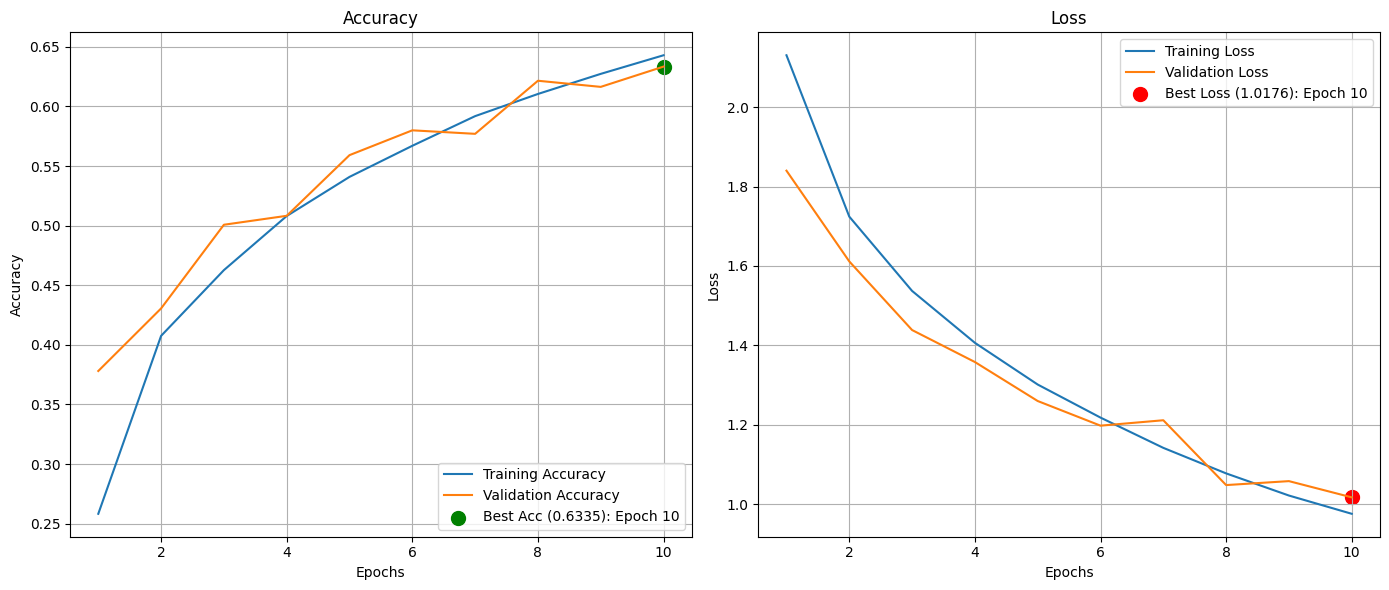

In [42]:
plot_learning_curves(history_viewcnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.63      0.93      0.75      4249
          06       0.00      0.00      0.00       401
          08       0.37      0.48      0.42      2748
          12       0.46      0.50      0.48      4633
          13       0.34      0.25      0.29      3429
          14       0.00      0.00      0.00      1139
          15       0.59      0.62      0.61      6421
          16       0.62      0.19      0.29      2061
          18       0.00      0.00      0.00      1058
          21       0.32      0.59      0.42      2899
          22       0.68      0.17      0.28       895
          23       0.44      0.62      0.52      2793
          27       0.94      0.33      0.49      1670
          30       0.94      0.32      0.47       803

    accuracy                           0.49     35199
   macro avg       0.45      0.36      0.36     35199
weighted avg       0.49      0.49      0.46     35

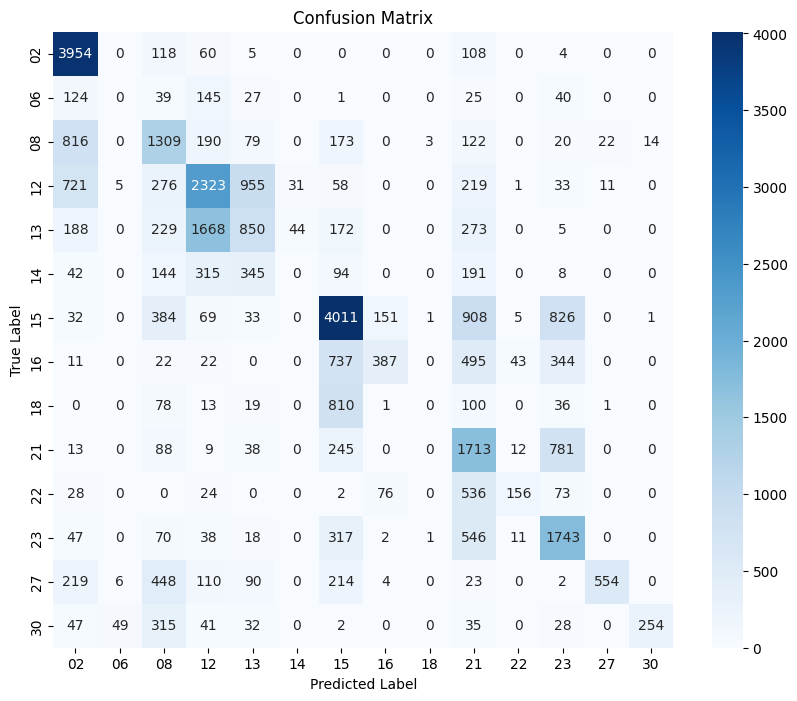

In [43]:
evaluate_model(trained_model_viewcnn, test_loader, base_dataset.classes)

In [44]:
save_model(trained_model_viewcnn, model_path_viewcnn, model_name_viewcnn)

Saved model weights for ViewCNN: ViewCNN.pth


### Load & Check Model

In [45]:
loaded_model_viewcnn = ViewCNN(num_classes=num_classes).to(DEVICE)

In [46]:
if not os.path.exists(BACKUP_DIR / model_path_viewcnn):
    raise FileNotFoundError(f"Model file not found: {model_path_viewcnn}")

In [ ]:
loaded_model_viewcnn.load_state_dict(torch.load(BACKUP_DIR / model_path_viewcnn))
loaded_model_viewcnn.eval()
evaluate_model(loaded_model_viewcnn, test_loader, base_dataset.classes)

## Optimized CNN

### Define Model

In [47]:
model_name_viewoptimizedcnn = "ViewOptimizedCNN"
model_path_viewoptimizedcnn = f"{model_name_viewoptimizedcnn}.pth"

In [48]:
class ViewOptimizedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ViewOptimizedCNN, self).__init__()
        
        # Block 1: Input (1, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Block 4: (128, 28, 28) -> (256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

### Train & Save Model

In [49]:
model_viewoptimizedcnn = ViewOptimizedCNN(num_classes=num_classes).to(DEVICE)

criterion_viewoptimizedcnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewoptimizedcnn = optim.Adam(model_viewoptimizedcnn.parameters(), lr=1e-3)

num_epochs_viewoptimizedcnn = 10

In [50]:
trained_model_viewoptimizedcnn, history_viewoptimizedcnn = train_model(model_name=model_name_viewoptimizedcnn,
                                                                       model=model_viewoptimizedcnn,
                                                                       criterion=criterion_viewoptimizedcnn,
                                                                       optimizer=optimizer_viewoptimizedcnn,
                                                                       train_loader=train_loader,
                                                                       val_loader=val_loader,
                                                                       num_epochs=num_epochs_viewoptimizedcnn)

Starting training ViewOptimizedCNN model for 10 epochs...

Epoch 1/10:
Train Loss: 1.0695 Acc: 0.6009
Val Loss: 1.2403 Acc: 0.6082


Epoch 2/10:
Train Loss: 0.4686 Acc: 0.8238
Val Loss: 0.8122 Acc: 0.6631


Epoch 3/10:
Train Loss: 0.2872 Acc: 0.8930
Val Loss: 5.8819 Acc: 0.3002


Epoch 4/10:
Train Loss: 0.1924 Acc: 0.9299
Val Loss: 0.5832 Acc: 0.8040


Epoch 5/10:
Train Loss: 0.1403 Acc: 0.9481
Val Loss: 2.3683 Acc: 0.6497


Epoch 6/10:
Train Loss: 0.1154 Acc: 0.9581
Val Loss: 0.1608 Acc: 0.9400


Epoch 7/10:
Train Loss: 0.0973 Acc: 0.9638
Val Loss: 0.3970 Acc: 0.8750


Epoch 8/10:
Train Loss: 0.0807 Acc: 0.9699
Val Loss: 0.5723 Acc: 0.8032


Epoch 9/10:
Train Loss: 0.0749 Acc: 0.9719
Val Loss: 0.4674 Acc: 0.8588


Epoch 10/10:
Train Loss: 0.0655 Acc: 0.9749
Val Loss: 2.6716 Acc: 0.6406


Best Val Acc:   0.9400
Best Train Acc: 0.9749


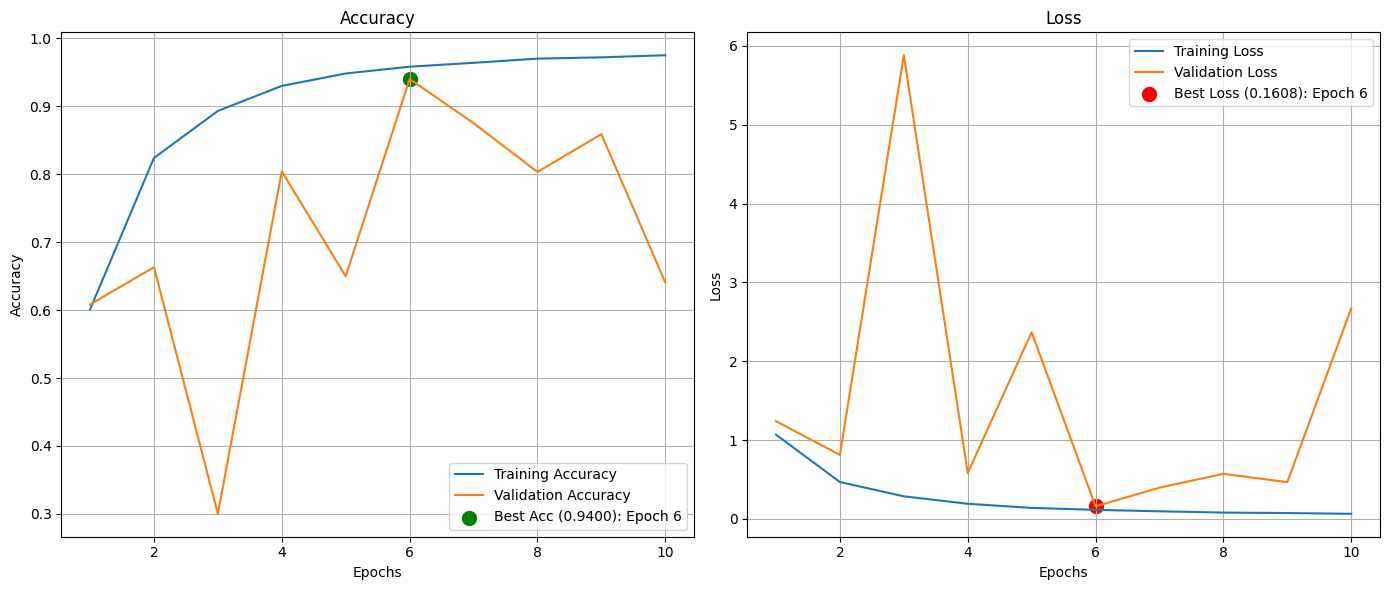

In [51]:
plot_learning_curves(history_viewoptimizedcnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.85      0.85      0.85      4249
          06       0.21      0.09      0.12       401
          08       0.84      0.30      0.44      2748
          12       0.58      0.38      0.46      4633
          13       0.36      0.67      0.47      3429
          14       0.14      0.10      0.12      1139
          15       0.78      0.73      0.75      6421
          16       0.42      0.76      0.54      2061
          18       0.30      0.02      0.04      1058
          21       0.66      0.46      0.54      2899
          22       0.21      0.41      0.28       895
          23       0.77      0.70      0.73      2793
          27       0.63      0.96      0.76      1670
          30       0.70      0.81      0.75       803

    accuracy                           0.59     35199
   macro avg       0.53      0.52      0.49     35199
weighted avg       0.63      0.59      0.58     35

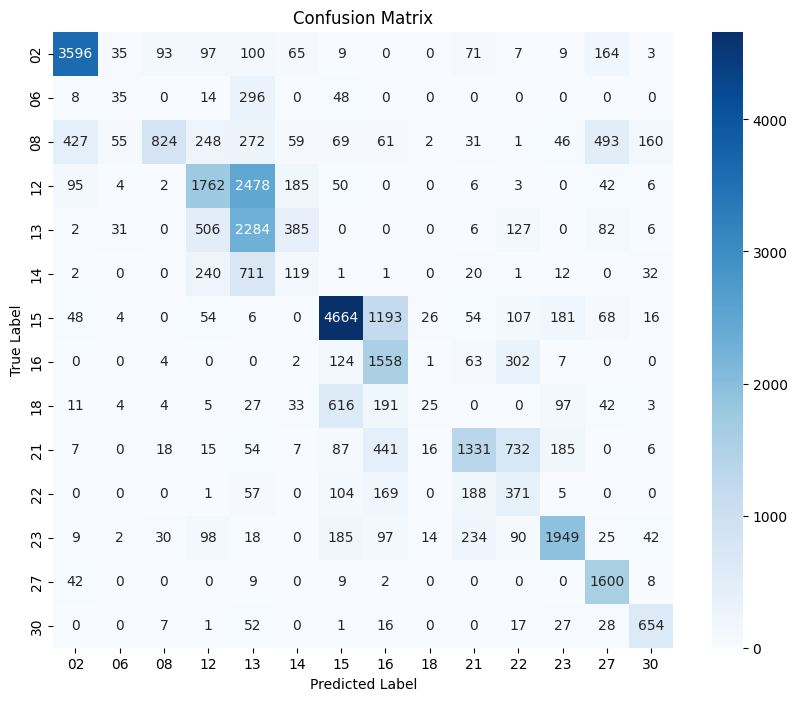

In [52]:
evaluate_model(trained_model_viewoptimizedcnn, test_loader, base_dataset.classes)

In [53]:
save_model(trained_model_viewoptimizedcnn, model_path_viewoptimizedcnn, model_name_viewoptimizedcnn)

Saved model weights for ViewOptimizedCNN: ViewOptimizedCNN.pth


### Load & Check Model

In [54]:
loaded_model_viewoptimizedcnn = ViewOptimizedCNN(num_classes=num_classes).to(DEVICE)

In [55]:
if not os.path.exists(BACKUP_DIR / model_path_viewoptimizedcnn):
    raise FileNotFoundError(f"Model file not found: {model_path_viewoptimizedcnn}")

In [ ]:
loaded_model_viewoptimizedcnn.load_state_dict(torch.load(BACKUP_DIR / model_path_viewoptimizedcnn))
loaded_model_viewoptimizedcnn.eval()
evaluate_model(loaded_model_viewoptimizedcnn, test_loader, base_dataset.classes)

## QNN (Hybrid)

### Define Model

In [56]:
n_qubits_qnn = 8
n_layers_qnn = 2

In [57]:
model_name_qnn = "HybridQNN"
model_path_qnn = f"{model_name_qnn}.pth"

In [58]:
# dev_qnn = qml.device('lightning.gpu', wires=n_qubits_qnn)
dev_qnn = qml.device('default.qubit', wires=n_qubits_qnn)

@qml.qnode(dev_qnn, interface='torch')
def quantum_circuit_qnn(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qnn))
    
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qnn))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qnn)]
    
weight_shapes_qnn = {"weights": (n_layers_qnn, n_qubits_qnn, 3)}

qlayer_qnn = qnn.TorchLayer(quantum_circuit_qnn, weight_shapes_qnn)

In [59]:
class HybridQNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc1 = nn.Linear(32, n_qubits_qnn)
        self.qlayer = qlayer_qnn
        self.fc2 = nn.Linear(n_qubits_qnn, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc2(x)
        return x

### Train & Save Model

In [60]:
model_qnn = HybridQNN(num_classes=num_classes).to(DEVICE)

criterion_qnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qnn = optim.Adam(model_qnn.parameters(), lr=1e-3)

num_epochs_qnn = 10

In [61]:
trained_model_qnn, history_qnn = train_model(model_name=model_name_qnn,
                                             model=model_qnn,
                                             criterion=criterion_qnn,
                                             optimizer=optimizer_qnn,
                                             train_loader=train_loader,
                                             val_loader=val_loader,
                                             num_epochs=num_epochs_qnn)

Starting training HybridQNN model for 10 epochs...

Epoch 1/10:
Train Loss: 2.5792 Acc: 0.1050
Val Loss: 2.3324 Acc: 0.1895


Epoch 2/10:
Train Loss: 2.0973 Acc: 0.2317
Val Loss: 1.9534 Acc: 0.2791


Epoch 3/10:
Train Loss: 1.8893 Acc: 0.2977
Val Loss: 1.7830 Acc: 0.3377


Epoch 4/10:
Train Loss: 1.7054 Acc: 0.3678
Val Loss: 1.6686 Acc: 0.4052


Epoch 5/10:
Train Loss: 1.5274 Acc: 0.4367
Val Loss: 1.4155 Acc: 0.4740


Epoch 6/10:
Train Loss: 1.3830 Acc: 0.4862
Val Loss: 1.3773 Acc: 0.4633


Epoch 7/10:
Train Loss: 1.2845 Acc: 0.5239
Val Loss: 1.3301 Acc: 0.5098


Epoch 8/10:
Train Loss: 1.2077 Acc: 0.5488
Val Loss: 1.2087 Acc: 0.5517


Epoch 9/10:
Train Loss: 1.1430 Acc: 0.5703
Val Loss: 1.1338 Acc: 0.5854


Epoch 10/10:
Train Loss: 1.0951 Acc: 0.5865
Val Loss: 1.0366 Acc: 0.5962


Best Val Acc:   0.5962
Best Train Acc: 0.5865


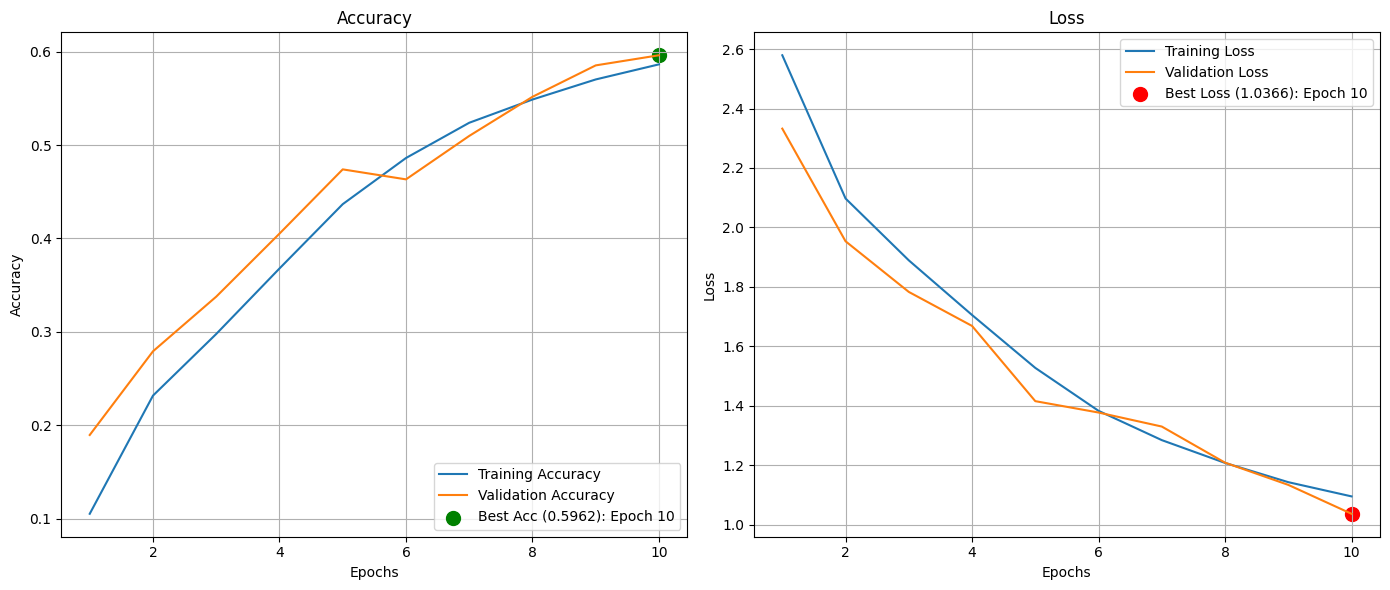

In [62]:
plot_learning_curves(history_qnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.82      0.81      0.82      4249
          06       0.01      0.02      0.02       401
          08       0.41      0.51      0.46      2748
          12       0.44      0.24      0.31      4633
          13       0.34      0.55      0.42      3429
          14       0.05      0.06      0.06      1139
          15       0.64      0.53      0.58      6421
          16       0.72      0.26      0.38      2061
          18       0.11      0.12      0.12      1058
          21       0.36      0.54      0.43      2899
          22       0.30      0.43      0.35       895
          23       0.28      0.30      0.29      2793
          27       0.70      0.59      0.64      1670
          30       0.78      0.35      0.48       803

    accuracy                           0.46     35199
   macro avg       0.43      0.38      0.38     35199
weighted avg       0.50      0.46      0.46     35

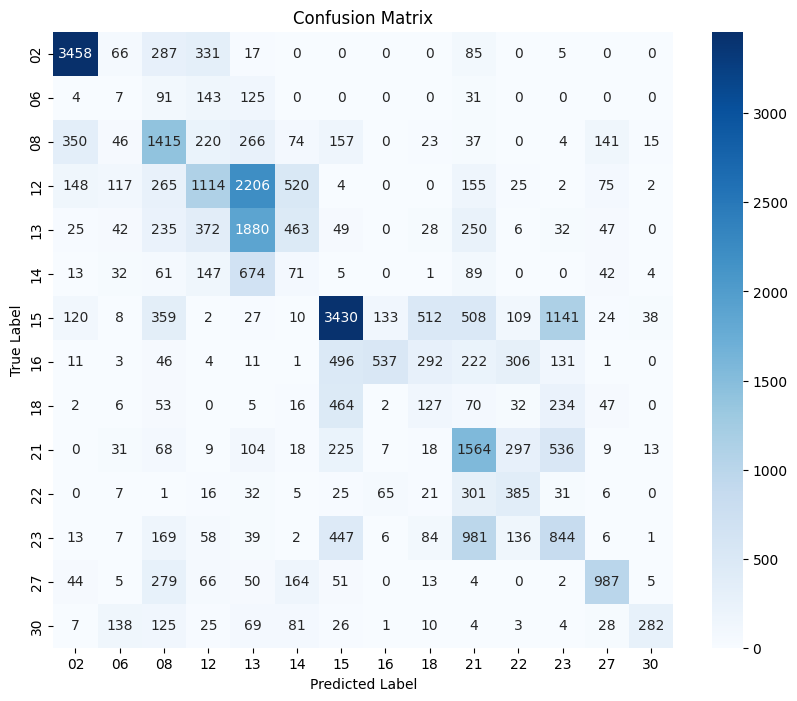

In [63]:
evaluate_model(trained_model_qnn, test_loader, base_dataset.classes)

In [64]:
save_model(trained_model_qnn, model_path_qnn, model_name_qnn)

Saved model weights for HybridQNN: HybridQNN.pth


### Load & Check Model

In [65]:
loaded_model_qnn = HybridQNN(num_classes=num_classes).to(DEVICE)

In [66]:
if not os.path.exists(BACKUP_DIR / model_path_qnn):
    raise FileNotFoundError(f"Model file not found: {model_path_qnn}")

In [ ]:
loaded_model_qnn.load_state_dict(torch.load(BACKUP_DIR / model_path_qnn))
loaded_model_qnn.eval()
evaluate_model(loaded_model_qnn, test_loader, base_dataset.classes)

## Optimized QNN (Hybrid)

### Define Model

In [67]:
n_qubits_optimizedqnn = 8
n_layers_optimizedqnn = 2

In [68]:
model_name_optimizedqnn = "HybridOptimizedQNN"
model_path_optimizedqnn = f"{model_name_optimizedqnn}.pth"

In [69]:
# dev_optimizedqnn  = qml.device('lightning.gpu', wires=n_qubits_optimizedqnn)
dev_optimizedqnn = qml.device('default.qubit', wires=n_qubits_optimizedqnn)

@qml.qnode(dev_optimizedqnn, interface='torch')
def quantum_circuit_optimizedqnn(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_optimizedqnn))
    
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_optimizedqnn))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_optimizedqnn)]
    
weight_shapes_optimizedqnn = {"weights": (n_layers_optimizedqnn, n_qubits_optimizedqnn, 3)}

qlayer_optimizedqnn = qnn.TorchLayer(quantum_circuit_optimizedqnn, weight_shapes_optimizedqnn)

In [70]:
class ViewOptimizedQNN(nn.Module):
    def __init__(self, num_classes):
        super(ViewOptimizedQNN, self).__init__()
        
        # Block 1: Input (1, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Block 4: (128, 28, 28) -> (256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
        self.fc_to_q = nn.Linear(512, n_qubits_optimizedqnn)
        self.qlayer = qlayer_optimizedqnn
        self.fc_out = nn.Linear(n_qubits_optimizedqnn, num_classes)
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = self.fc_to_q(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc_out(x)
        
        return x

### Train & Save Model

In [71]:
model_optimizedqnn = ViewOptimizedQNN(num_classes=num_classes).to(DEVICE)

criterion_optimizedqnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_optimizedqnn = optim.Adam(model_optimizedqnn.parameters(), lr=1e-3)

num_epochs_optimizedqnn = 10

In [72]:
trained_model_optimizedqnn, history_optimizedqnn = train_model(model_name=model_name_optimizedqnn,
                                                               model=model_optimizedqnn,
                                                               criterion=criterion_optimizedqnn,
                                                               optimizer=optimizer_optimizedqnn,
                                                               train_loader=train_loader,
                                                               val_loader=val_loader,
                                                               num_epochs=num_epochs_optimizedqnn)

Starting training HybridOptimizedQNN model for 10 epochs...

Epoch 1/10:
Train Loss: 2.0173 Acc: 0.2373
Val Loss: 1.9399 Acc: 0.2716


Epoch 2/10:
Train Loss: 1.4213 Acc: 0.4072
Val Loss: 1.4021 Acc: 0.4349


Epoch 3/10:
Train Loss: 0.9936 Acc: 0.6212
Val Loss: 0.9079 Acc: 0.6801


Epoch 4/10:
Train Loss: 0.7088 Acc: 0.7235
Val Loss: 1.2080 Acc: 0.6155


Epoch 5/10:
Train Loss: 0.5536 Acc: 0.7776
Val Loss: 0.7991 Acc: 0.7012


Epoch 6/10:
Train Loss: 0.4318 Acc: 0.8230
Val Loss: 0.5142 Acc: 0.8305


Epoch 7/10:
Train Loss: 0.3521 Acc: 0.8511
Val Loss: 0.2856 Acc: 0.8874


Epoch 8/10:
Train Loss: 0.2968 Acc: 0.8740
Val Loss: 0.2946 Acc: 0.8769


Epoch 9/10:
Train Loss: 0.2576 Acc: 0.8937
Val Loss: 0.3060 Acc: 0.8954


Epoch 10/10:
Train Loss: 0.2225 Acc: 0.9129
Val Loss: 0.5174 Acc: 0.8523


Best Val Acc:   0.8954
Best Train Acc: 0.9129


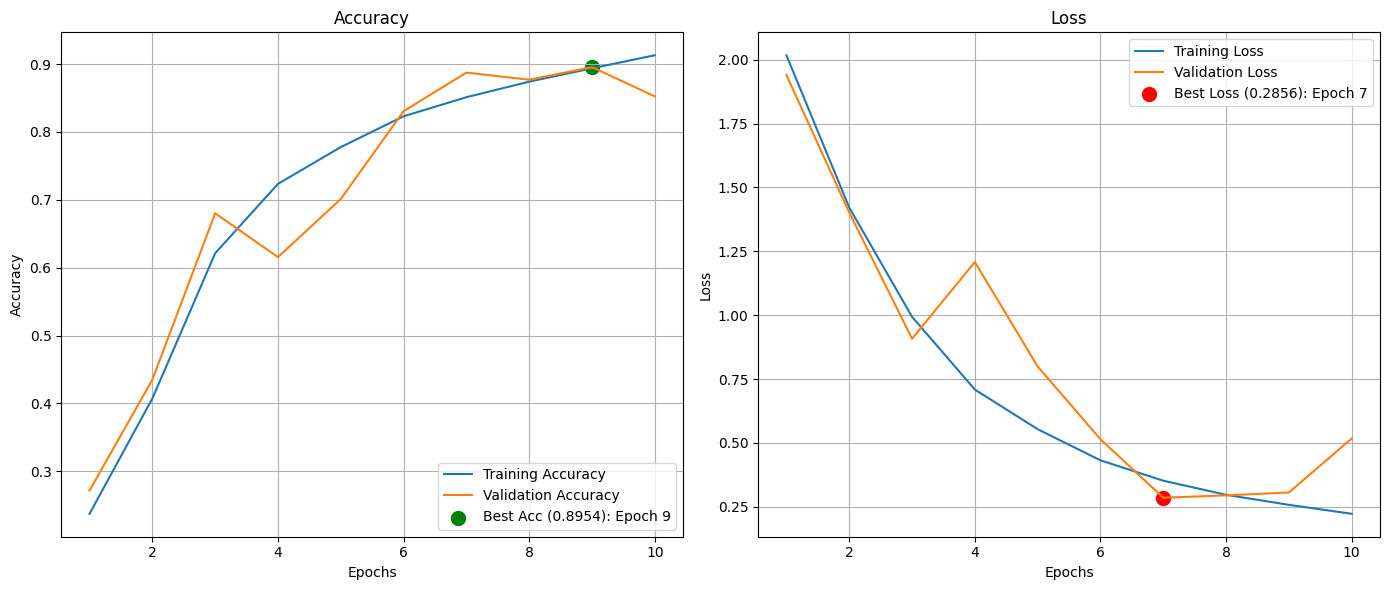

In [73]:
plot_learning_curves(history_optimizedqnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.68      0.92      0.79      4249
          06       0.00      0.00      0.00       401
          08       0.76      0.40      0.53      2748
          12       0.51      0.68      0.59      4633
          13       0.55      0.45      0.50      3429
          14       0.17      0.07      0.10      1139
          15       0.53      0.87      0.66      6421
          16       0.60      0.29      0.39      2061
          18       0.06      0.09      0.07      1058
          21       0.75      0.26      0.39      2899
          22       0.11      0.02      0.04       895
          23       0.56      0.42      0.48      2793
          27       0.74      0.82      0.78      1670
          30       0.89      0.50      0.64       803

    accuracy                           0.56     35199
   macro avg       0.49      0.41      0.42     35199
weighted avg       0.57      0.56      0.53     35

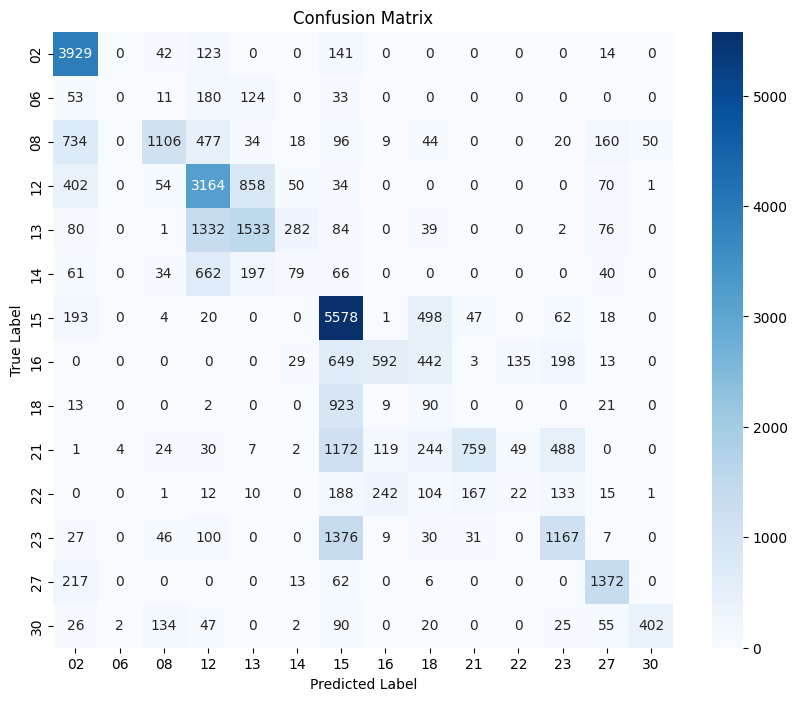

In [74]:
evaluate_model(trained_model_optimizedqnn, test_loader, base_dataset.classes)

In [75]:
save_model(trained_model_optimizedqnn, model_path_optimizedqnn, model_name_optimizedqnn)

Saved model weights for HybridOptimizedQNN: HybridOptimizedQNN.pth


### Load & Check Model

In [76]:
loaded_model_optimizedqnn = ViewOptimizedQNN(num_classes=num_classes).to(DEVICE)

In [77]:
if not os.path.exists(BACKUP_DIR / model_path_optimizedqnn):
    raise FileNotFoundError(f"Model file not found: {model_path_optimizedqnn}")

In [ ]:
loaded_model_optimizedqnn.load_state_dict(torch.load(BACKUP_DIR / model_path_optimizedqnn))
loaded_model_optimizedqnn.eval()
evaluate_model(loaded_model_optimizedqnn, test_loader, base_dataset.classes)

## Optimized ResNet

### Define Model

In [78]:
model_name_viewoptimizedresnet = "ViewOptimizedResNet"
model_path_viewoptimizedresnet = f"{model_name_viewoptimizedresnet}.pth"

In [79]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        
        # First convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

class ViewOptimizedResNet(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(ViewOptimizedResNet, self).__init__()
        
        # Initial Convolution
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet Layers
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial processing
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Output Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

### Train & Save Model

In [80]:
model_viewoptimizedresnet = ViewOptimizedResNet(num_classes=num_classes).to(DEVICE)

criterion_viewoptimizedresnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewoptimizedresnet = optim.Adam(model_viewoptimizedresnet.parameters(), lr=1e-3)

num_epochs_viewoptimizedresnet = 10

In [81]:
trained_model_viewoptimizedresnet, history_viewoptimizedresnet = train_model(model_name=model_name_viewoptimizedresnet,
                                                                             model=model_viewoptimizedresnet,
                                                                             criterion=criterion_viewoptimizedresnet,
                                                                             optimizer=optimizer_viewoptimizedresnet,
                                                                             train_loader=train_loader,
                                                                             val_loader=val_loader,
                                                                             num_epochs=num_epochs_viewoptimizedresnet)

Starting training ViewOptimizedResNet model for 10 epochs...

Epoch 1/10:
Train Loss: 0.2707 Acc: 0.9010
Val Loss: 0.0777 Acc: 0.9708


Epoch 2/10:
Train Loss: 0.0516 Acc: 0.9793
Val Loss: 0.0601 Acc: 0.9760


Epoch 3/10:
Train Loss: 0.0351 Acc: 0.9838
Val Loss: 0.0555 Acc: 0.9754


Epoch 4/10:
Train Loss: 0.0267 Acc: 0.9864
Val Loss: 0.0206 Acc: 0.9873


Epoch 5/10:
Train Loss: 0.0228 Acc: 0.9875
Val Loss: 0.0371 Acc: 0.9832


Epoch 6/10:
Train Loss: 0.0206 Acc: 0.9879
Val Loss: 0.0156 Acc: 0.9894


Epoch 7/10:
Train Loss: 0.0186 Acc: 0.9886
Val Loss: 0.0198 Acc: 0.9878


Epoch 8/10:
Train Loss: 0.0186 Acc: 0.9885
Val Loss: 0.0152 Acc: 0.9889


Epoch 9/10:
Train Loss: 0.0161 Acc: 0.9895
Val Loss: 0.0281 Acc: 0.9851


Epoch 10/10:
Train Loss: 0.0162 Acc: 0.9895
Val Loss: 0.0159 Acc: 0.9890


Best Val Acc:   0.9894
Best Train Acc: 0.9895


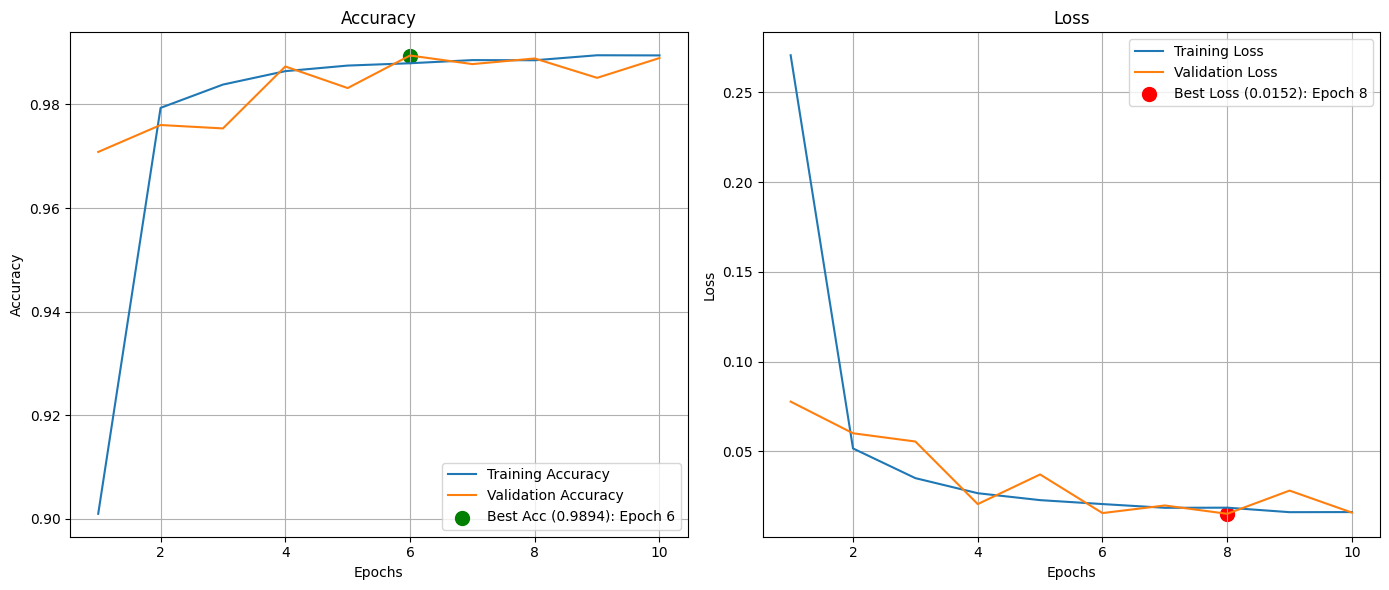

In [82]:
plot_learning_curves(history_viewoptimizedresnet)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.96      0.93      0.94      4249
          06       0.76      0.15      0.25       401
          08       0.79      0.88      0.83      2748
          12       0.60      0.74      0.66      4633
          13       0.50      0.48      0.49      3429
          14       0.39      0.16      0.22      1139
          15       0.86      0.95      0.90      6421
          16       0.83      0.63      0.72      2061
          18       0.75      0.66      0.71      1058
          21       0.79      0.87      0.83      2899
          22       0.73      0.36      0.49       895
          23       0.91      0.87      0.89      2793
          27       0.93      0.89      0.91      1670
          30       0.82      0.95      0.88       803

    accuracy                           0.78     35199
   macro avg       0.76      0.68      0.69     35199
weighted avg       0.77      0.78      0.77     35

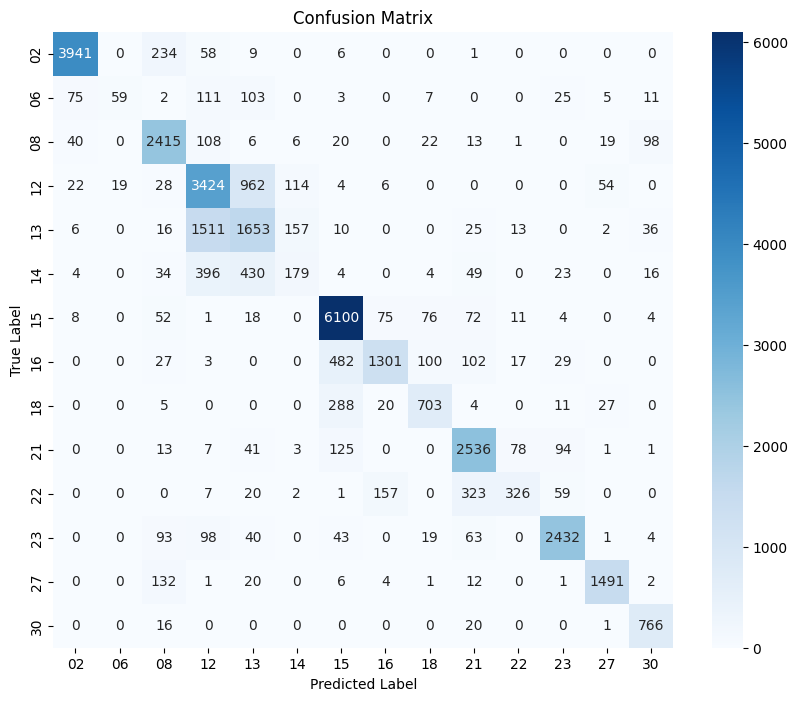

In [83]:
evaluate_model(trained_model_viewoptimizedresnet, test_loader, base_dataset.classes)

In [84]:
save_model(trained_model_viewoptimizedresnet, model_path_viewoptimizedresnet, model_name_viewoptimizedresnet)

Saved model weights for ViewOptimizedResNet: ViewOptimizedResNet.pth


### Load & Check Model

In [85]:
loaded_model_viewoptimizedresnet = ViewOptimizedResNet(num_classes=num_classes).to(DEVICE)

In [86]:
if not os.path.exists(BACKUP_DIR / model_path_viewoptimizedresnet):
    raise FileNotFoundError(f"Model file not found: {model_path_viewoptimizedresnet}")

In [ ]:
loaded_model_viewoptimizedresnet.load_state_dict(torch.load(BACKUP_DIR / model_path_viewoptimizedresnet))
loaded_model_viewoptimizedresnet.eval()
evaluate_model(loaded_model_viewoptimizedresnet, test_loader, base_dataset.classes)

## Optimized ResNet (KFold)

In [ ]:
cv_results = cross_validate_model(
    model_class=ViewOptimizedResNet,
    train_dataset=base_dataset,
    num_epochs=10,
    k_folds=5,
    num_workers=NUM_WORKERS
)

In [ ]:
print("Classification Report for all Folds:")
for i in range(5):
    loaded_model_fold = ViewOptimizedResNet(num_classes=num_classes).to(DEVICE)
    model_path_fold = f"ViewOptimizedResNet_Fold{i+1}.pth"

    if not os.path.exists(BACKUP_DIR / model_path_fold):
        raise FileNotFoundError(f"Model file not found: {model_path_fold}")

    print(f"   FOLD {i+1}:")
    loaded_model_fold.load_state_dict(torch.load(BACKUP_DIR / model_path_fold))
    loaded_model_fold.eval()
    evaluate_model(loaded_model_fold, test_loader, base_dataset.classes)

## Optimized QResNet

### Define Model

In [87]:
n_qubits_optimizedqresnet = 8
n_layers_optimizedqresnet = 2

In [88]:
model_name_optimizedqresnet = "ViewOptimizedQResNet"
model_path_optimizedqresnet = f"{model_name_optimizedqresnet}.pth"

In [89]:
dev_optimizedqresnet = qml.device('default.qubit', wires=n_qubits_optimizedqresnet)
# dev_optimizedqresnet = qml.device('lightning.gpu', wires=n_qubits_optimizedqresnet)

@qml.qnode(dev_optimizedqresnet, interface='torch')
def quantum_circuit_optimizedqresnet(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_optimizedqresnet))
    
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_optimizedqresnet))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_optimizedqresnet)]
    
weight_shapes_optimizedqresnet = {"weights": (n_layers_optimizedqresnet, n_qubits_optimizedqresnet, 3)}

qlayer_optimizedqresnet = qnn.TorchLayer(quantum_circuit_optimizedqresnet, weight_shapes_optimizedqresnet)

In [90]:
class ViewOptimizedQResNet(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(ViewOptimizedQResNet, self).__init__()
        
        # Initial Convolution
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet Layers
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc_to_q = nn.Linear(512, n_qubits_optimizedqresnet)
        self.qlayer = qlayer_optimizedqresnet
        self.fc_out = nn.Linear(n_qubits_optimizedqresnet, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial processing
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Output Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Quantum Block
        x = self.fc_to_q(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc_out(x)

        return x

### Train & Save Model

In [91]:
model_optimizedqresnet = ViewOptimizedQResNet(num_classes=num_classes).to(DEVICE)

criterion_optimizedqresnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_optimizedqresnet = optim.Adam(model_optimizedqresnet.parameters(), lr=1e-3)

num_epochs_optimizedqresnet = 10

In [92]:
trained_model_optimizedqresnet, history_optimizedqresnet = train_model(model_name=model_name_optimizedqresnet,
                                                                       model=model_optimizedqresnet,
                                                                       criterion=criterion_optimizedqresnet,
                                                                       optimizer=optimizer_optimizedqresnet,
                                                                       train_loader=train_loader,
                                                                       val_loader=val_loader,
                                                                       num_epochs=num_epochs_optimizedqresnet)

Starting training ViewOptimizedQResNet model for 10 epochs...

Epoch 1/10:
Train Loss: 2.0491 Acc: 0.2335
Val Loss: 1.4381 Acc: 0.3087


Epoch 2/10:
Train Loss: 1.1308 Acc: 0.5122
Val Loss: 0.7688 Acc: 0.7027


Epoch 3/10:
Train Loss: 0.5752 Acc: 0.8141
Val Loss: 0.2607 Acc: 0.9464


Epoch 4/10:
Train Loss: 0.1929 Acc: 0.9564
Val Loss: 0.1256 Acc: 0.9787


Epoch 5/10:
Train Loss: 0.0953 Acc: 0.9799
Val Loss: 0.0724 Acc: 0.9824


Epoch 6/10:
Train Loss: 0.0622 Acc: 0.9846
Val Loss: 0.0385 Acc: 0.9884


Epoch 7/10:
Train Loss: 0.0445 Acc: 0.9866
Val Loss: 0.0332 Acc: 0.9886


Epoch 8/10:
Train Loss: 0.0385 Acc: 0.9870
Val Loss: 0.0245 Acc: 0.9886


Epoch 9/10:
Train Loss: 0.0305 Acc: 0.9881
Val Loss: 0.0263 Acc: 0.9894


Epoch 10/10:
Train Loss: 0.0289 Acc: 0.9878
Val Loss: 0.0248 Acc: 0.9876


Best Val Acc:   0.9894
Best Train Acc: 0.9881


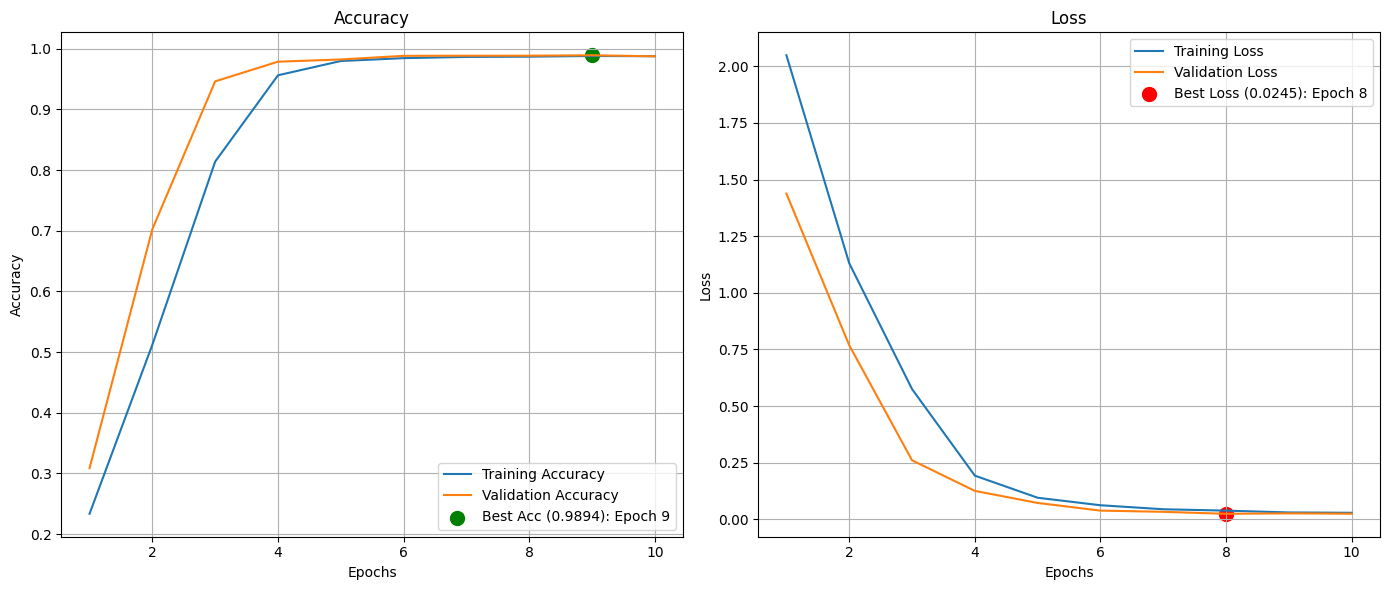

In [93]:
plot_learning_curves(history_optimizedqresnet)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.87      0.93      0.90      4249
          06       0.41      0.14      0.21       401
          08       0.84      0.80      0.82      2748
          12       0.55      0.67      0.61      4633
          13       0.40      0.41      0.41      3429
          14       0.14      0.03      0.05      1139
          15       0.87      0.86      0.87      6421
          16       0.77      0.61      0.68      2061
          18       0.33      0.60      0.43      1058
          21       0.75      0.79      0.77      2899
          22       0.69      0.69      0.69       895
          23       0.94      0.80      0.86      2793
          27       0.82      0.87      0.84      1670
          30       1.00      0.75      0.86       803

    accuracy                           0.72     35199
   macro avg       0.67      0.64      0.64     35199
weighted avg       0.72      0.72      0.72     35

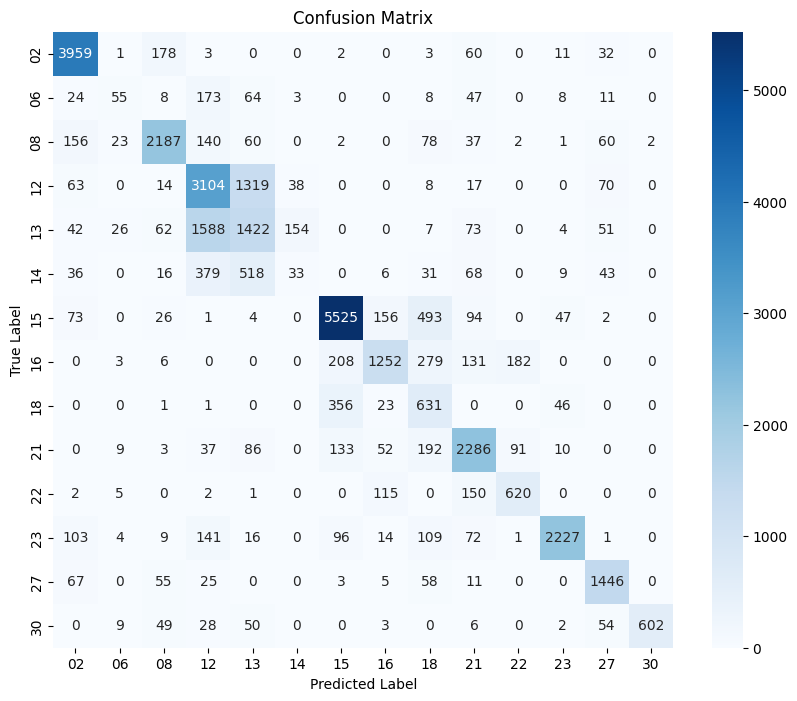

In [94]:
evaluate_model(trained_model_optimizedqresnet, test_loader, base_dataset.classes)

In [95]:
save_model(trained_model_optimizedqresnet, model_path_optimizedqresnet, model_name_optimizedqresnet)

Saved model weights for ViewOptimizedQResNet: ViewOptimizedQResNet.pth


### Load & Check Model

In [96]:
loaded_model_optimizedqresnet = HybridQNN(num_classes=num_classes).to(DEVICE)

In [97]:
if not os.path.exists(BACKUP_DIR / model_path_optimizedqresnet):
    raise FileNotFoundError(f"Model file not found: {model_path_optimizedqresnet}")

In [ ]:
loaded_model_optimizedqresnet.load_state_dict(torch.load(BACKUP_DIR / model_path_optimizedqresnet))
loaded_model_optimizedqresnet.eval()
evaluate_model(loaded_model_optimizedqresnet, test_loader, base_dataset.classes)

## ResNet (Hybrid) + Quantum Head

### Define Model

In [ ]:
n_qubits_qresnetqhead = 8
n_layers_qresnetqhead = 2

In [ ]:
model_name_qresnetqhead = "ResNetQuantumHead"
model_path_qresnetqhead = f"{model_name_qresnetqhead}.pth"

In [ ]:
dev_qresnetqhead = qml.device('default.qubit', wires=n_qubits_qresnetqhead)

@qml.qnode(dev_qresnetqhead, interface='torch')
def quantum_circuit_qresnetqhead(inputs, weights):

    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qresnetqhead))

    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qresnetqhead))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qresnetqhead)]
    
weight_shapes_qresnet = {'weights': (n_layers_qresnetqhead, n_qubits_qresnetqhead, 3)}

qlayer_qresnetqhead = qnn.TorchLayer(quantum_circuit_qresnetqhead, weight_shapes_qresnetqhead)

In [ ]:
class ResNetQuantumHead(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base = base_model
        in_features = self.base.fc.in_features
        self.base.fc = nn.Identity()
        self.fc1 = nn.Linear(in_features, n_qubits_qresnet)
        self.q_layer = qlayer_qresnet
        self.fc_out = nn.Linear(n_qubits_qresnet, num_classes)

    def forward(self, x):
        x = self.base(x)
        x = self.fc1(x)
        x = torch.tanh(x) * math.pi
        x = self.q_layer(x)
        x = self.fc_out(x)
        return x

In [ ]:
backbone = models.resnet18(weights=None)
backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

### Train & Save Model

In [ ]:
model_qresnetqhead = ResNetQuantumHead(base_model=backbone, num_classes=num_classes).to(DEVICE)

criterion_qresnetqhead = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qresnetqhead = optim.Adam(model_qresnetqhead.parameters(), lr=1e-3)

num_epochs_qresnetqhead = 10

In [ ]:
trained_model_qresnetqhead, history_qresnetqhead = train_model(model_name=model_name_qresnetqhead,
                                                               model=model_qresnetqhead,
                                                               criterion=criterion_qresnetqhead,
                                                               optimizer=optimizer_qresnetqhead,
                                                               train_loader=train_loader,
                                                               val_loader=val_loader,
                                                               num_epochs=num_epochs_qresnetqhead)

In [ ]:
plot_learning_curves(history_qresnetqhead)

In [ ]:
evaluate_model(trained_model_qresnetqhead, test_loader, base_dataset.classes)

In [ ]:
save_model(trained_model_qresnetqhead, model_path_qresnetqhead, model_name_qresnetqhead)